# 2 - Distribuições — Forma das distribuições e transformações candidatas

## Objetivo

Caracterizar a **forma da distribuição** de cada variável (simetria, normalidade, outliers) e identificar quais precisam de transformação (log, Box-Cox, Yeo-Johnson) antes de alimentar a GAIN.

## Pergunta que responde

> Quais variáveis são razoavelmente simétricas e quais precisam de transformação antes de alimentar a GAIN?

## Posição na Etapa 1 — EDA

Notebook **2 de 6**. Responde à segunda das 5 perguntas-meta:

1. Quais variáveis têm boa cobertura e quais são críticas? → `01_descritivo.ipynb`
2. **Quais variáveis são simétricas vs assimétricas?** ← *este notebook*
3. Quais pares são correlacionados? → `03_correlacoes.ipynb`
4. Há padrão temporal? → `04_temporal.ipynb`
5. As estações são distintas? → `05_estacoes.ipynb`
6. A censura é estruturada? → `06_lds.ipynb`

## Hipótese

Esperamos:

- Variáveis biológicas (Coliformes, Cianobactérias) e de nutrientes (Fósforo, Nitrato) fortemente **assimétricas à direita** — eventos extremos puxam a média.
- Variáveis físico-químicas (pH, Temperatura da Água) razoavelmente **simétricas** — operam em faixas estreitas.
- Microcistinas pode ser bimodal: presença/ausência de florações.

O notebook `01_descritivo.ipynb` já indicou skewness alta em Fósforo (~13), Condutividade/Turbidez (~9) e Nitrato (~9). Aqui formalizamos e decidimos a transformação.

## Resumo executivo

- Três variáveis são simétricas o suficiente para dispensar transformação: pH (skew = 0,71), Temperatura da Água (0,24) e Microcistinas (0,68; n = 52 limitado). Todas as demais apresentam assimetria forte e exigem transformação.
- Sete variáveis recebem Box-Cox (Nitrato, Fósforo Total, Condutividade, Turbidez, Sólidos Suspensos Totais, Coliformes Termotolerantes e Cianobactérias; λ entre -0,39 e 0,38); três recebem Yeo-Johnson por terem zeros (DBO, OD e Nitrogênio Amoniacal Total).
- As transformações reduzem o skewness a valores próximos de zero na quase totalidade dos casos; a exceção é Fósforo Total, que mantém kurtosis residual elevada (8,9) mesmo após Box-Cox (λ = -0,13) — eventos extremos genuínos que a GAIN deverá modelar com atenção especial.


## Setup

Imports, caminhos e constantes. Os caminhos são relativos a este notebook (`Code/2 - EDA/02_distribuicoes.ipynb`).

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH   = Path("../../Data/IntermediaryData/WaterQualityInitialData.xlsx")
OUTPUT_BASE = Path("../../Data/Figures/01_EDA")
FIG_DIR     = OUTPUT_BASE / "figuras"
TAB_DIR     = OUTPUT_BASE / "tabelas"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

VARS = [
    "DBO", "OD", "Nitrato", "Nitrogênio Amoniacal Total", "Fósforo Total",
    "Condutividade", "pH", "Turbidez", "Temperatura da Água",
    "Sólidos Suspensos Totais", "Coliformes Termotolerantes",
    "Cianobacterias", "Microcistinas",
]

MIN_N = 8         # n mínimo para testes estatísticos
SKEW_THRESHOLD = 1.0  # |skew| acima disso → variável "assimétrica

## Carregamento

Lê o dataset consolidado e isola as 13 colunas numéricas de interesse.

In [7]:
df = pd.read_excel(DATA_PATH)
print(f"Shape: {df.shape}")

Shape: (657, 30)


**Sanidade:**

- 13 colunas presentes.
- `count` por coluna bate com a `n_obs` reportada em `01_descritivo`.
- Domínio: todas as variáveis são não-negativas (esperado para qualidade de água); algumas têm zeros (DBO, OD, alguns nutrientes).

⚠️ A presença de zeros importa para a escolha da transformação: **Box-Cox exige valores estritamente positivos**; **Yeo-Johnson aceita zeros e negativos**.

## 1. Estatísticas de forma e testes de normalidade

Para cada variável calculamos:

| Métrica         | O que indica                                                                |
| --------------- | --------------------------------------------------------------------------- |
| `skew`          | assimetria. `>0` cauda à direita; `<0` à esquerda; `|skew| < 0.5` ≈ simétrica |
| `kurtosis`      | "peso" da cauda (Fisher, normal = 0). `> 3` cauda pesada (muitos outliers)   |
| `shapiro_p`     | teste Shapiro-Wilk de normalidade. `p < 0.05` → rejeita normalidade          |
| `anderson_stat` | estatística Anderson-Darling. Quanto **maior**, mais longe da normalidade    |

Os testes estatísticos rejeitam normalidade com facilidade em n grande — então usamos skew/kurtosis como guia principal e os testes como confirmação.

In [8]:
def shape_stats(series: pd.Series, min_n: int = MIN_N) -> dict:
    """Estatísticas de forma + testes de normalidade. Retorna NaN onde n insuficiente."""
    s = series.dropna()
    n = len(s)
    out = {"n": n, "skew": np.nan, "kurtosis": np.nan,
           "shapiro_p": np.nan, "anderson_stat": np.nan}
    if n < min_n:
        return out
    out["skew"] = float(s.skew())
    out["kurtosis"] = float(s.kurtosis())
    try:
        out["shapiro_p"] = float(stats.shapiro(s).pvalue)
    except Exception:
        pass
    try:
        out["anderson_stat"] = float(stats.anderson(s, dist="norm").statistic)
    except Exception:
        pass
    return out


rows = [{"variavel": v, **shape_stats(df[v])} for v in VARS]
tab_forma = pd.DataFrame(rows).set_index("variavel")
tab_forma

C:\Users\jhter\AppData\Local\Temp\ipykernel_11360\700749308.py:16: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  out["anderson_stat"] = float(stats.anderson(s, dist="norm").statistic)


,n,skew,kurtosis,shapiro_p,anderson_stat
variavel,,,,,
DBO,642,3.774478,26.036292,2.068301e-31,29.866638
OD,635,1.190609,1.863571,7.255373e-18,10.772825
Nitrato,337,8.683852,88.903525,2.046810e-35,96.793617
Nitrogênio Amoniacal Total,497,3.393398,15.905322,9.636246e-30,36.796940
Fósforo Total,624,13.375227,182.537088,9.474165e-48,233.976585
Condutividade,635,9.247846,160.709982,3.787658e-36,22.802348
pH,639,0.707894,1.184858,9.782258e-11,6.004518
Turbidez,631,9.541697,114.970872,1.100024e-42,97.220604
Temperatura da Água,629,0.242927,-0.236355,7.462692e-06,3.328804


**Como ler:**

- **`|skew| < 0.5`** → praticamente simétrica, não precisa de transformação.
- **`0.5 ≤ |skew| < 1.0`** → moderadamente assimétrica, transformação é opcional.
- **`|skew| ≥ 1.0`** → fortemente assimétrica, transformação fortemente recomendada.
- **`kurtosis > 3`** → cauda pesada (outliers); transformação log/Box-Cox geralmente também ajuda aqui.
- **`shapiro_p`** sempre será muito baixo em `n > 100` mesmo com leve não-normalidade — interpretar com cuidado.

**Achados específicos:**

- **Simétricas (|skew| < 1):** pH (0,71) e Temperatura da Água (0,24) confirmam o comportamento esperado de variáveis físico-químicas estáveis. Microcistinas (0,68) também está abaixo do limiar, mas o n = 52 é insuficiente para conclusões robustas.
- **Assimetria extrema (|skew| > 8):** Fósforo Total (13,4), Turbidez (9,5), Condutividade (9,2) e Nitrato (8,7) — valores que confirmam a necessidade imediata de transformação.
- **Kurtosis altíssima:** Fósforo Total (182,5), Nitrato (88,9), Turbidez (115) e Condutividade (160,7) indicam caudas extremamente pesadas com eventos muito raros e muito intensos.
- **Shapiro-Wilk**: normalidade rejeitada em todas as variáveis (todos os p < 0,05), o que era esperado para n > 100 com distribuições assimétricas. O teste é mais informativo aqui para confirmar do que para descobrir.


## 2. Histogramas

Grade de histogramas, uma variável por subplot. Procurar:

- **Caudas longas** (skew alto).
- **Distribuições "encavaladas em zero"** (DBO, Nitrato, Microcistinas — muitos valores baixos com outliers extremos).
- **Bimodalidade** — duas modas separadas (relevante para a GAIN, que precisa cobrir os dois modos).
- **Picos artificiais** — concentração em um valor (pode ser efeito do limite de detecção).

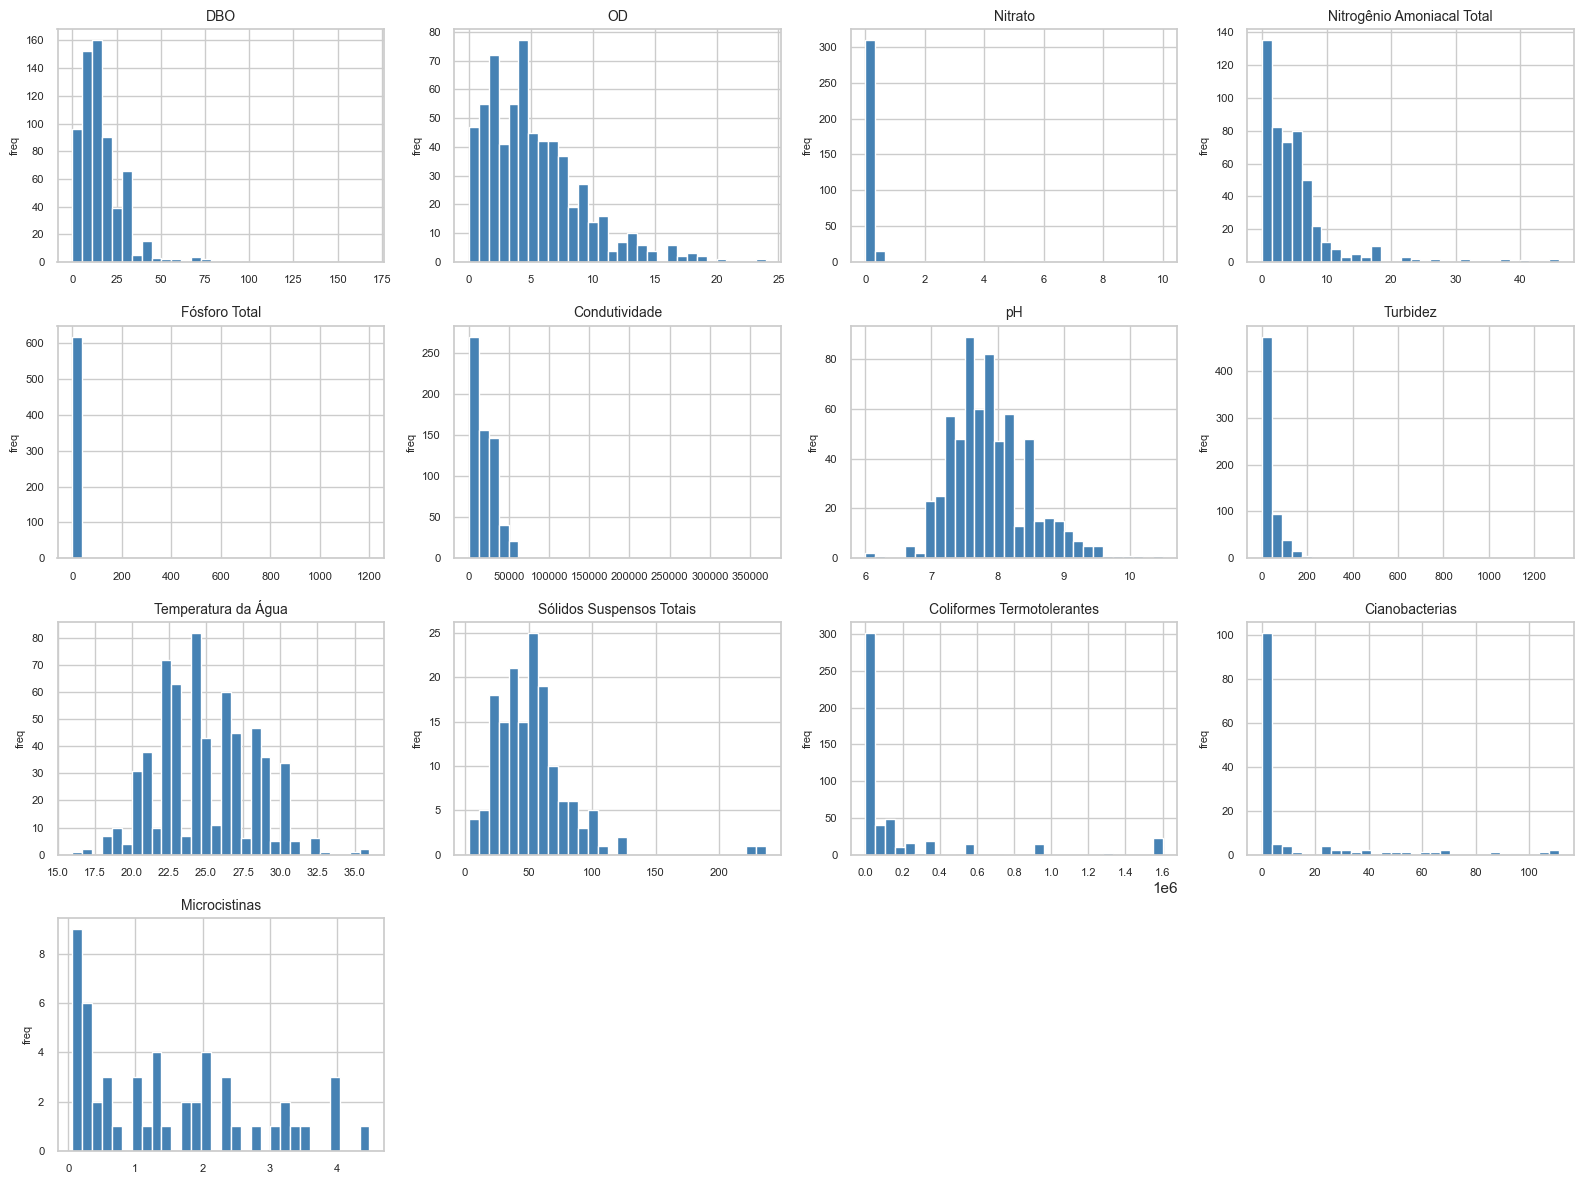

In [9]:
def plot_grid_dist(df: pd.DataFrame, vars_: list[str], kind: str, ncols: int = 4):
    """Grid de histogramas ou boxplots, um subplot por variável."""
    nrows = (len(vars_) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for ax, v in zip(axes, vars_):
        s = df[v].dropna()
        if kind == "hist":
            ax.hist(s, bins=30, color="steelblue", edgecolor="white")
            ax.set_ylabel("freq", fontsize=8)
        elif kind == "box":
            ax.boxplot(s, vert=True, showmeans=True,
                       meanprops={"marker": "D", "markerfacecolor": "darkorange",
                                  "markeredgecolor": "darkorange", "markersize": 5})
            ax.set_xticks([1]); ax.set_xticklabels([""])
        ax.set_title(v, fontsize=10)
        ax.tick_params(labelsize=8)
    for ax in axes[len(vars_):]:
        ax.axis("off")
    plt.tight_layout()
    return fig


fig = plot_grid_dist(df, VARS, kind="hist", ncols=4)
fig.savefig(FIG_DIR / "dist_histogramas.png", dpi=150)
plt.show()

**Como interpretar:**

- Variáveis com distribuição "encaixada à esquerda" e cauda longa à direita → precisam de transformação log/Box-Cox.
- Picos isolados em valores baixos podem ser indício de censura (`<` no LD) ou de medições no piso do método analítico.

**Achados específicos:**

- **Cauda direita intensa:** Fósforo Total, Turbidez, Condutividade, Nitrato, Coliformes Termotolerantes e Cianobactérias apresentam distribuição fortemente encaixada à esquerda com barra dominante nos valores baixos e cauda muito longa — confirmam necessidade de transformação.
- **Concentração próxima de zero:** DBO (1 zero), OD (29 zeros) e Nitrogênio Amoniacal Total (10 zeros) têm pico em valores muito baixos, impedindo o uso de Box-Cox e justificando Yeo-Johnson.
- **Piso de detecção visível:** Nitrato mostra concentração elevada no valor mínimo (0,01), reflexo da censura inferior — consistente com os 22% censurados identificados em `01_descritivo.ipynb`.
- **pH e Temperatura da Água:** histogramas aproximadamente simétricos, com uma única moda central e sem caudas expressivas — confirmam dispensa de transformação.
- **Microcistinas:** distribuição irregular com leve sugestão de bimodalidade (concentração em valores baixos e um segundo grupo de florações), mas n = 52 impede confirmação.


## 3. Boxplots

Grade de boxplots para visualizar dispersão, quartis e **outliers**. Variáveis com muitos pontos acima do whisker superior (1.5 × IQR) indicam:

- Necessidade de transformação que comprima a escala.
- OU genuína presença de eventos extremos (florações de cianobactérias, picos de coliformes em chuva).

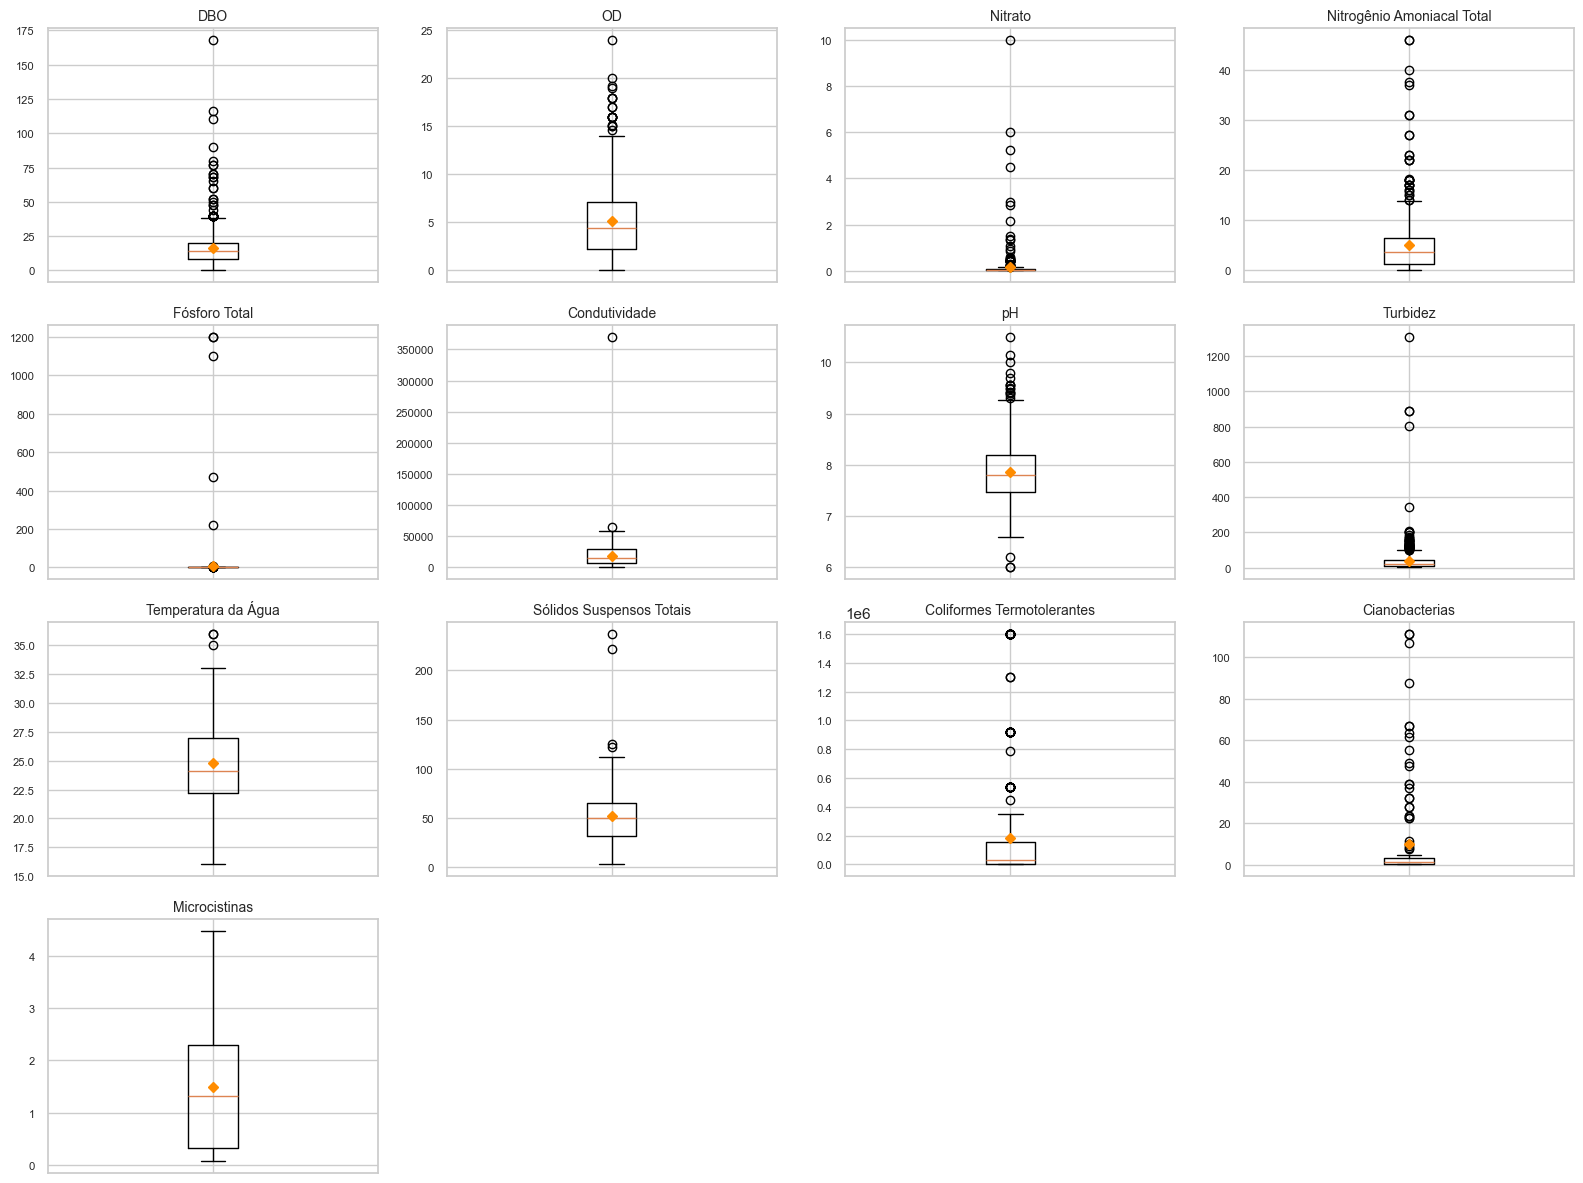

In [10]:
fig = plot_grid_dist(df, VARS, kind="box", ncols=4)
fig.savefig(FIG_DIR / "dist_boxplots.png", dpi=150)
plt.show()

**Como interpretar:**

- Caixa achatada com muitos pontos acima → cauda direita extrema.
- Distância entre média (losango laranja) e mediana (linha) → assimetria visível.

**Achados específicos:**

- **Fósforo Total, Turbidez, Condutividade e Nitrato:** boxplots praticamente achatados em zero com dezenas de pontos extremos acima do whisker; a média (losango laranja) está muito acima da mediana, confirmando assimetria severa.
- **Coliformes Termotolerantes e Cianobactérias:** caixa compacta com vários outliers extremos isolados — eventos de floração e contaminação bacteriana pontual.
- **DBO e Nitrogênio Amoniacal Total:** cauda direita moderada, com média visivelmente acima da mediana, mas o padrão é menos extremo que os anteriores.
- **pH e Temperatura da Água:** boxplots simétricos com IQR bem distribuído e poucos ou nenhum outlier — confirmam comportamento próximo da normal.
- **Sólidos Suspensos Totais:** caixa razoável, mas com alguns outliers acima; compatível com o skew de 2,6 observado na tabela de forma.


## 4. Q-Q plots vs distribuição normal

Cada subplot compara os quantis da variável (eixo Y) com os quantis teóricos da distribuição normal (eixo X). Se a variável é normal, os pontos seguem a reta vermelha.

Desvios típicos:

- **Linha curvada para cima nas pontas** → caudas mais pesadas que normal (kurtosis alta).
- **Linha em "S"** → assimetria.
- **Pontos formando degraus** → poucos valores discretos (variável quase-discreta).

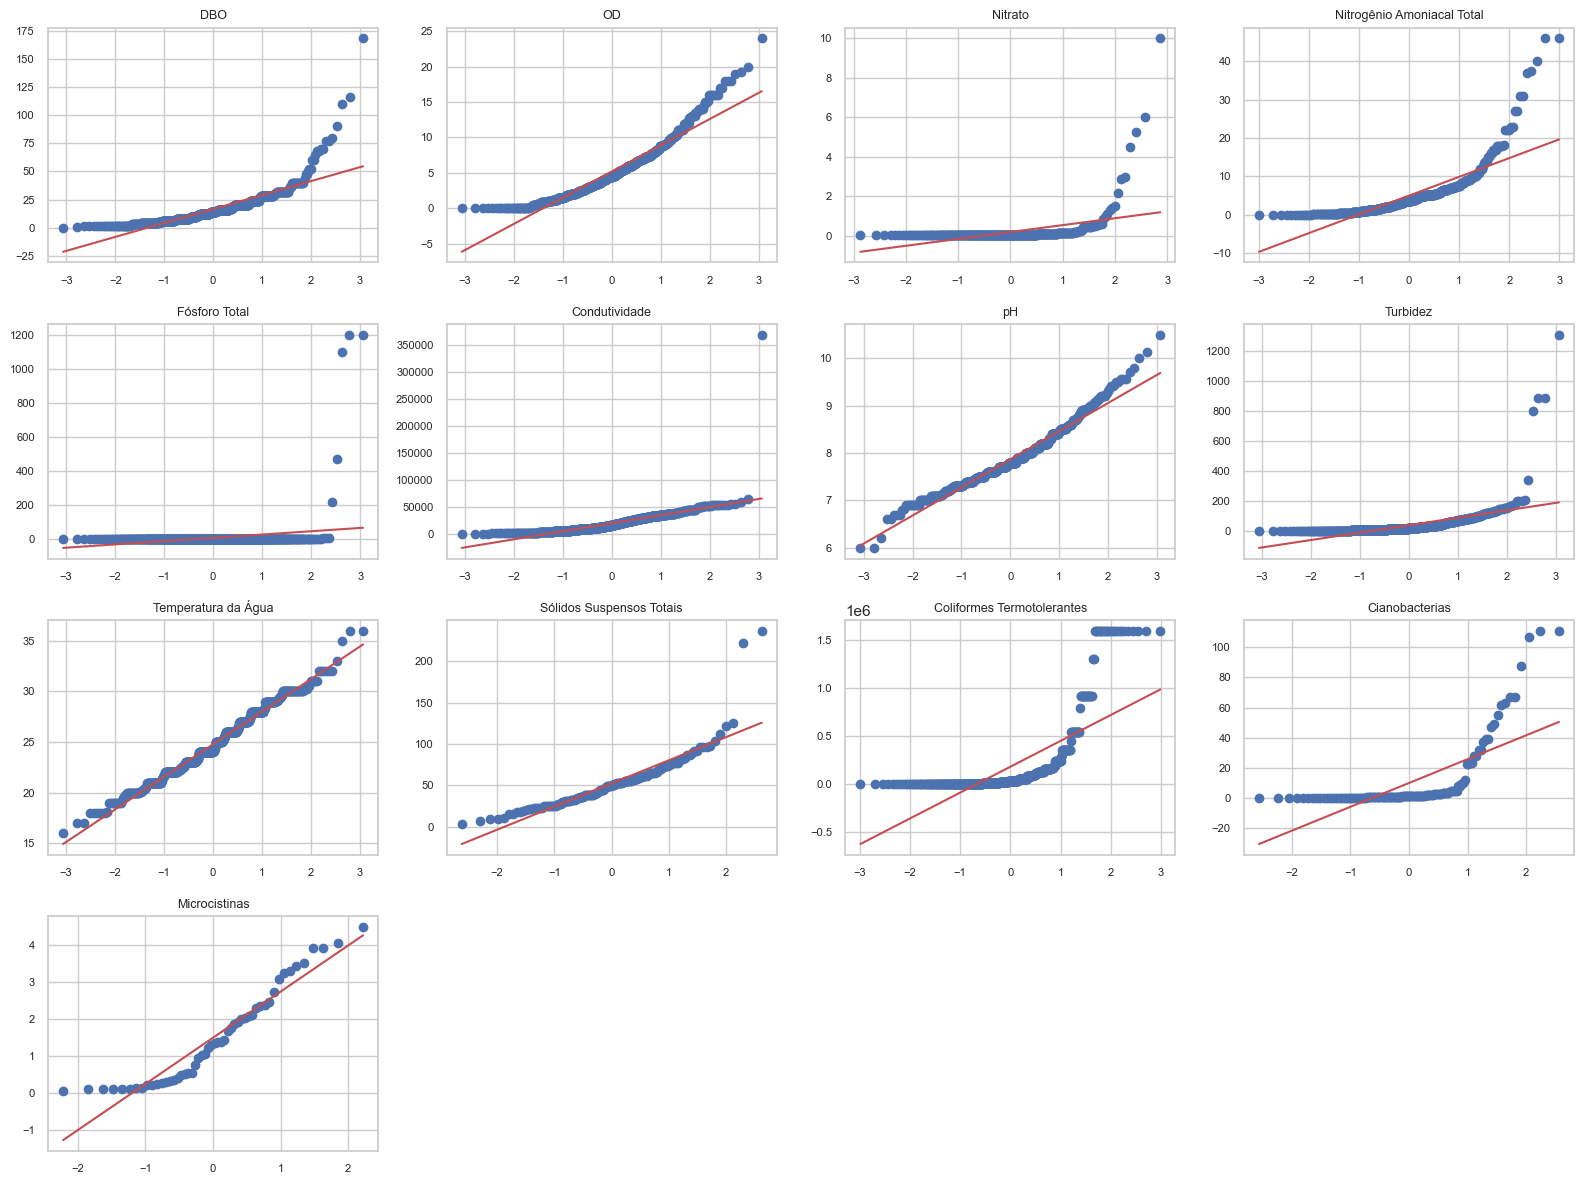

In [11]:
def plot_qqplot_grid(df: pd.DataFrame, vars_: list[str], data_fn=None, title_suffix: str = "", ncols: int = 4):
    """Q-Q plots em grade. `data_fn(series) → array` permite transformar antes de plotar."""
    nrows = (len(vars_) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for ax, v in zip(axes, vars_):
        s = df[v].dropna()
        if len(s) < MIN_N:
            ax.text(0.5, 0.5, "n insuficiente", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(v, fontsize=9)
            continue
        data = s.values if data_fn is None else data_fn(s)
        stats.probplot(data, dist="norm", plot=ax)
        title = v + (f" ({title_suffix})" if title_suffix else "")
        ax.set_title(title, fontsize=9)
        ax.tick_params(labelsize=8)
        ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[len(vars_):]:
        ax.axis("off")
    plt.tight_layout()
    return fig


fig = plot_qqplot_grid(df, VARS, ncols=4)
fig.savefig(FIG_DIR / "dist_qqplots.png", dpi=150)
plt.show()

**Como interpretar:**

- Pontos próximos da reta → variável próxima de normal.
- Desvios sistemáticos confirmam o que a `skew`/`kurtosis` indicaram.

**Achados específicos:**

- **pH e Temperatura da Água:** pontos próximos da reta em toda a extensão — confirmam simetria e proximidade com a distribuição normal.
- **Fósforo Total, Turbidez, Condutividade e Nitrato:** desvios sistemáticos expressivos nas caudas superiores, formando uma curva ascendente acentuada — distribuição muito mais pesada que a normal.
- **DBO, OD e Nitrogênio Amoniacal Total:** padrão em "S" com concentração de pontos no canto inferior esquerdo (zeros e valores baixos) e desvio nas caudas — assimetria e inflação de zeros visíveis.
- **Cianobactérias e Microcistinas:** padrão irregular e pontos esparsos, reflexo do n reduzido (133 e 52) e da concentração nos extremos.
- Os Q-Q plots confirmam que todas as variáveis com `|skew| ≥ 1` precisam de transformação antes de alimentar a GAIN.


## 5. Transformações candidatas

Regra de decisão:

1. Se `|skew| < SKEW_THRESHOLD (=1.0)` → `'identidade'` (sem transformação).
2. Se variável **estritamente positiva** (`min > 0`) e assimétrica → `'boxcox'` (estimar λ via MLE).
3. Se variável tem **zeros ou negativos** e é assimétrica → `'yeo-johnson'` (aceita não-positivos).

O λ retornado pelo Box-Cox/Yeo-Johnson é persistido em `dist_resumo.csv` e usado na Etapa 2 para aplicar a mesma transformação na pipeline da GAIN.

In [12]:
def suggest_transformation(series: pd.Series) -> str:
    s = series.dropna()
    if len(s) < MIN_N:
        return "identidade"
    if abs(s.skew()) < SKEW_THRESHOLD:
        return "identidade"
    return "boxcox" if (s > 0).all() else "yeo-johnson"


def apply_transformation(series: pd.Series, tipo: str):
    """Retorna (Series transformada, lambda). Lambda é None se sem transformação."""
    s = series.dropna()
    if tipo == "identidade" or len(s) < MIN_N:
        return s.copy(), None
    if tipo == "boxcox":
        transformed, lmbda = stats.boxcox(s.values)
        return pd.Series(transformed, index=s.index), float(lmbda)
    if tipo == "yeo-johnson":
        transformed, lmbda = stats.yeojohnson(s.values)
        return pd.Series(transformed, index=s.index), float(lmbda)
    raise ValueError(f"Tipo desconhecido: {tipo!r}")


resultados = []
for v in VARS:
    s = df[v].dropna()
    tipo = suggest_transformation(s)
    transformed, lmbda = apply_transformation(s, tipo)
    resultados.append({
        "variavel":               v,
        "n":                      len(s),
        "skew_antes":             float(s.skew())     if len(s) >= MIN_N else np.nan,
        "kurtosis_antes":         float(s.kurtosis()) if len(s) >= MIN_N else np.nan,
        "transformacao_sugerida": tipo,
        "lambda_boxcox":          lmbda,
        "skew_depois":            float(transformed.skew())     if tipo != "identidade" and len(transformed) >= MIN_N else float(s.skew())     if len(s) >= MIN_N else np.nan,
        "kurtosis_depois":        float(transformed.kurtosis()) if tipo != "identidade" and len(transformed) >= MIN_N else float(s.kurtosis()) if len(s) >= MIN_N else np.nan,
    })

tab_transf = pd.DataFrame(resultados).set_index("variavel")
tab_transf

,n,skew_antes,kurtosis_antes,transformacao_sugerida,lambda_boxcox,skew_depois,kurtosis_depois
variavel,,,,,,,
DBO,642,3.774478,26.036292,yeo-johnson,0.078256,0.004198,0.277489
OD,635,1.190609,1.863571,yeo-johnson,0.282396,-0.023842,-0.304452
Nitrato,337,8.683852,88.903525,boxcox,-0.393525,0.189103,-1.030114
Nitrogênio Amoniacal Total,497,3.393398,15.905322,yeo-johnson,-0.078446,0.006360,-0.328037
Fósforo Total,624,13.375227,182.537088,boxcox,-0.134624,-0.400415,8.915127
Condutividade,635,9.247846,160.709982,boxcox,0.381782,0.079258,2.250003
pH,639,0.707894,1.184858,identidade,NaN,0.707894,1.184858
Turbidez,631,9.541697,114.970872,boxcox,0.027852,0.000971,0.108838
Temperatura da Água,629,0.242927,-0.236355,identidade,NaN,0.242927,-0.236355


**Como ler:**

- `skew_depois` próximo de zero → transformação foi eficaz.
- `lambda_boxcox` ≈ 0 indica transformação próxima de `log`; λ ≈ 0.5 indica `sqrt`; λ ≈ 1 indica que a transformação foi quase identidade (skew já era baixa).
- Variáveis em `identidade` não receberão transformação na Etapa 2.

**Achados específicos:**

- **Transformações altamente eficazes:** DBO (skew: 3,77 → 0,004), OD (1,19 → -0,024), Nitrogênio Amoniacal Total (3,39 → 0,006), Condutividade (9,25 → 0,079), Turbidez (9,54 → 0,001) e Coliformes Termotolerantes (2,89 → -0,034) — skewness praticamente eliminado.
- **Caso mais difícil — Fósforo Total:** Box-Cox (λ = -0,13) reduz skew de 13,4 para -0,40, mas a kurtosis residual é elevada (8,9) — eventos extremos genuínos persistem e não são capturados pela transformação.
- **λ ≈ 0 (equivalente ao log):** Turbidez (λ = 0,028) e Coliformes Termotolerantes (λ = 0,069) — transformação log simples seria uma boa aproximação.
- **Yeo-Johnson por presença de zeros:** DBO (1 zero), OD (29 zeros) e Nitrogênio Amoniacal Total (10 zeros) não poderiam usar Box-Cox; Yeo-Johnson foi igualmente eficaz.
- **Identidade (sem transformação):** pH (skew = 0,71), Temperatura da Água (0,24) e Microcistinas (0,68; n = 52 insuficiente para transformação confiável).


## 6. Q-Q plots após transformação

Refazer o Q-Q plot com a variável transformada (onde aplicável). Para variáveis em `identidade`, plota o dado original (para comparação direta com a Seção 4).

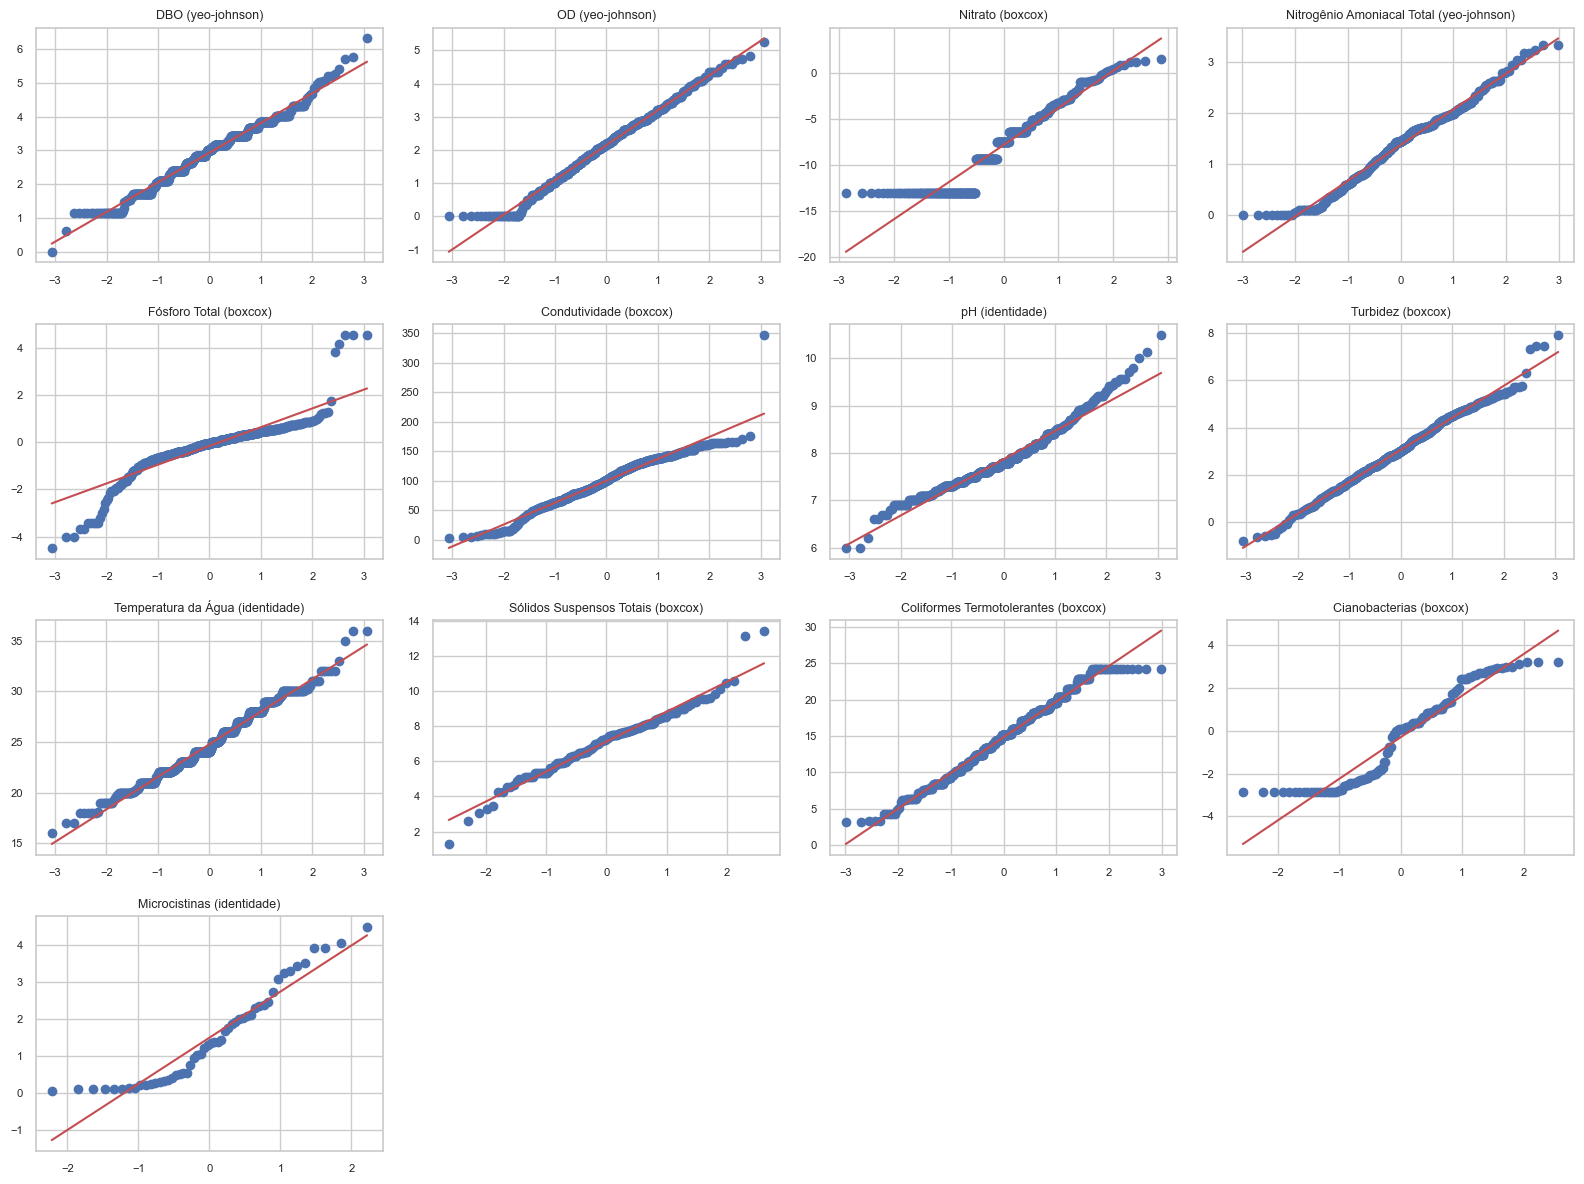

In [13]:
def transform_for_qqplot(v: str):
    """Closure que retorna a função de transformação apropriada para a variável."""
    tipo = tab_transf.loc[v, "transformacao_sugerida"]
    def _fn(s: pd.Series):
        if tipo == "identidade":
            return s.values
        out, _ = apply_transformation(s, tipo)
        return out.values
    return _fn


# Função auxiliar que despacha por variável dentro do plot_qqplot_grid
def plot_qqplot_grid_transformed(df, vars_, ncols=4):
    nrows = (len(vars_) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axes = axes.flatten()
    for ax, v in zip(axes, vars_):
        s = df[v].dropna()
        tipo = tab_transf.loc[v, "transformacao_sugerida"]
        if len(s) < MIN_N:
            ax.text(0.5, 0.5, "n insuficiente", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(f"{v} ({tipo})", fontsize=9)
            continue
        data = s.values if tipo == "identidade" else apply_transformation(s, tipo)[0].values
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{v} ({tipo})", fontsize=9)
        ax.tick_params(labelsize=8)
        ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[len(vars_):]:
        ax.axis("off")
    plt.tight_layout()
    return fig


fig = plot_qqplot_grid_transformed(df, VARS, ncols=4)
fig.savefig(FIG_DIR / "dist_qqplots_log.png", dpi=150)
plt.show()

**Como interpretar:**

- Comparar lado a lado com `dist_qqplots.png` (Seção 4). Variáveis com transformação aplicada devem ter pontos visivelmente mais próximos da reta vermelha.
- Caudas extremas que permanecem fora da reta mesmo após transformação indicam que ainda há eventos extremos genuínos — a GAIN precisará lidar com isso.

**Achados específicos:**

- **Melhoria expressiva:** DBO, OD, Nitrogênio Amoniacal Total, Condutividade, Turbidez, Coliformes Termotolerantes e Sólidos Suspensos Totais apresentam pontos claramente mais alinhados com a reta após transformação — Q-Q quase perfeitos em vários casos.
- **Fósforo Total:** melhoria visível no corpo central, mas os extremos superiores ainda se afastam da reta, confirmando a kurtosis residual elevada (8,9). A GAIN deve modelar esses picos com cuidado para não subestimar eventos de eutrofização.
- **Cianobactérias e Nitrato:** melhoria moderada; leve desvio nas caudas permanece, mas dentro do aceitável dado o n disponível.
- **Identidade (pH, Temperatura da Água, Microcistinas):** pontos idênticos à Seção 4 (sem mudança esperada), confirmando que essas variáveis não necessitam de transformação.


## 7. Persistência consolidada

Consolida estatísticas de forma + decisões de transformação em `dist_resumo.csv` — entregável principal deste notebook.

In [14]:
tab_resumo = tab_forma.join(tab_transf[["transformacao_sugerida", "lambda_boxcox", "skew_depois", "kurtosis_depois"]])
tab_resumo.to_csv(TAB_DIR / "dist_resumo.csv", float_format="%.4g")
tab_resumo

,n,skew,kurtosis,shapiro_p,anderson_stat,transformacao_sugerida,lambda_boxcox,skew_depois,kurtosis_depois
variavel,,,,,,,,,
DBO,642,3.774478,26.036292,2.068301e-31,29.866638,yeo-johnson,0.078256,0.004198,0.277489
OD,635,1.190609,1.863571,7.255373e-18,10.772825,yeo-johnson,0.282396,-0.023842,-0.304452
Nitrato,337,8.683852,88.903525,2.046810e-35,96.793617,boxcox,-0.393525,0.189103,-1.030114
Nitrogênio Amoniacal Total,497,3.393398,15.905322,9.636246e-30,36.796940,yeo-johnson,-0.078446,0.006360,-0.328037
Fósforo Total,624,13.375227,182.537088,9.474165e-48,233.976585,boxcox,-0.134624,-0.400415,8.915127
Condutividade,635,9.247846,160.709982,3.787658e-36,22.802348,boxcox,0.381782,0.079258,2.250003
pH,639,0.707894,1.184858,9.782258e-11,6.004518,identidade,NaN,0.707894,1.184858
Turbidez,631,9.541697,114.970872,1.100024e-42,97.220604,boxcox,0.027852,0.000971,0.108838
Temperatura da Água,629,0.242927,-0.236355,7.462692e-06,3.328804,identidade,NaN,0.242927,-0.236355


## Síntese final

### Achados principais

1. **Variáveis simétricas (sem transformação):** pH (skew = 0,71), Temperatura da Água (0,24) e Microcistinas (0,68; n = 52 limitado). Essas três entram na GAIN com os valores originais.
2. **Variáveis que receberão Box-Cox:** Nitrato (λ = -0,39), Fósforo Total (λ = -0,13), Condutividade (λ = 0,38), Turbidez (λ = 0,03), Sólidos Suspensos Totais (λ = 0,29), Coliformes Termotolerantes (λ = 0,07) e Cianobactérias (λ = -0,18); λ entre -0,39 e 0,38.
3. **Variáveis que receberão Yeo-Johnson:** DBO (λ = 0,08), OD (λ = 0,28) e Nitrogênio Amoniacal Total (λ = -0,08) — têm zeros, impedindo o uso de Box-Cox.
4. **Variáveis com cauda pesada residual após transformação:** Fósforo Total (kurtosis_depois = 8,9) — alerta para a GAIN: eventos extremos de eutrofização podem ser subestimados pelo modelo.
5. **Variáveis problemáticas:** Cianobactérias (n = 133) e Microcistinas (n = 52) com amostras muito reduzidas, dificultando a avaliação da distribuição; Microcistinas apresenta sugestão de bimodalidade (ausência vs. presença de florações) que o n não permite confirmar.

### Decisões propagadas

- `02_Preprocessing/01_transformacoes.ipynb` lê `dist_resumo.csv` e aplica `transformacao_sugerida` por variável usando `lambda_boxcox` armazenado.
- Fósforo Total com kurtosis residual alta merece atenção no `04_GAIN/03_diagnostico.ipynb` — verificar se o gerador cobre os extremos.
- Turbidez (λ ≈ 0,03) e Coliformes Termotolerantes (λ ≈ 0,07): usar log simples seria uma boa aproximação caso a pipeline necessite de maior interpretabilidade.
